## Metrica acc_at_least_one y acc_both vs interations

### Mnist - Crop

Usando mnist como dataset


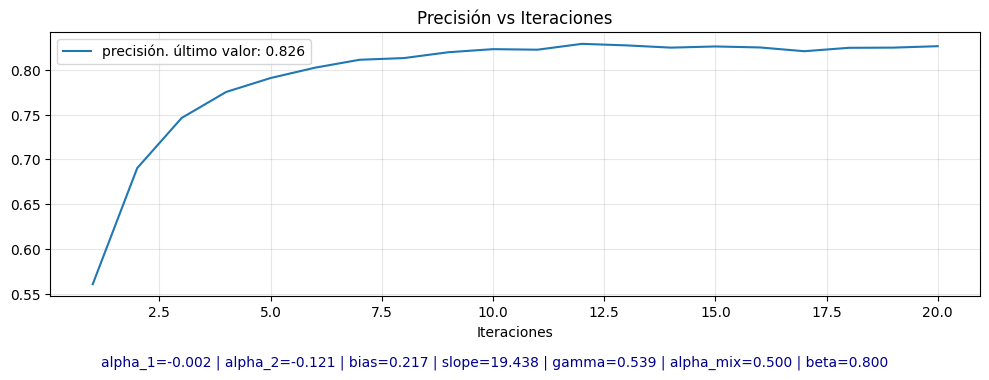


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.002
alpha_2   : -0.121
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 0.800

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.332  std:2.785
mask_bpsnr       : mean: 13.213  std:1.849
ssim             : mean: 0.765  std:0.104
acc_at_least_one : 0.985
acc_both         : 0.826



In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader
from project.CROP.models.crop2 import Crop2

dataset = "mnist"
model="crop2"
lat=128
inter=256
cvae = Loader.cvae(lat=lat,inter=inter,dataset=dataset)
data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]


#mnist
mnist_params ={'bias': 0.21716868437244724, 'slope': 19.437646607877017, 'alpha_1': -0.13863158439804657, 'alpha_2': -10.463749682840565, 'gamma': 0.5392507616026618,'beta': 0.9852458636805829}
params={'bias': 0.17789722652867873, 'slope': 13.529858722742809, 'gamma': 0.3427098856922591, 'alpha_1': -0.2707339212169495, 'beta': 0.9852458636805829},
c = Crop2(cvae=cvae,predictor=predictor)

resuts=c.unmix(x_test[:],
    x_test_1[:],
     y_test[:],
     y_test_1[:],
     iterations=20,
     params=mnist_params,
     #name=f"acc_vs_iterations_{dataset}_{model}_inter_{inter}_lat_{lat}_{mnist_params}",
     show_acc_curve=True)


## varios modelos


Usando mnist como dataset


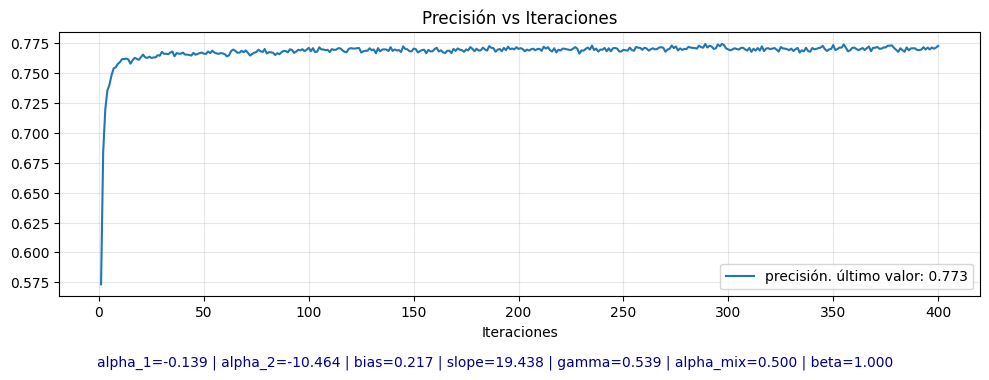


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 17.193  std:2.476
mask_bpsnr       : mean: 11.675  std:1.892
ssim             : mean: 0.720  std:0.103
acc_at_least_one : 0.981
acc_both         : 0.773



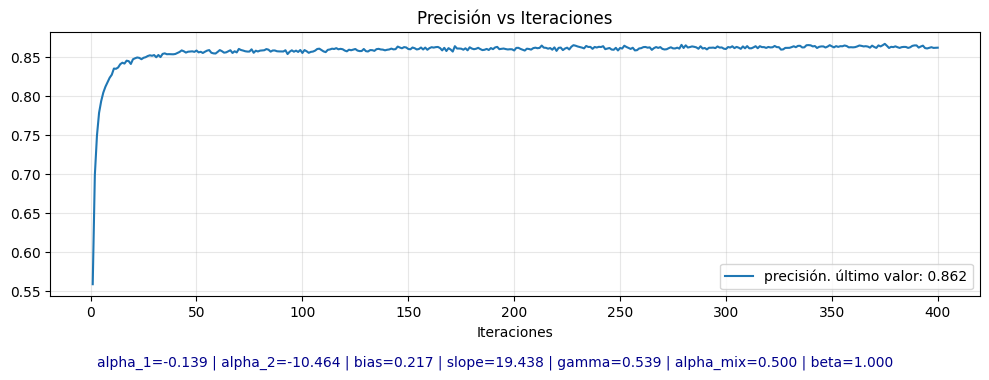


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.842  std:2.731
mask_bpsnr       : mean: 13.532  std:1.781
ssim             : mean: 0.787  std:0.095
acc_at_least_one : 0.990
acc_both         : 0.862



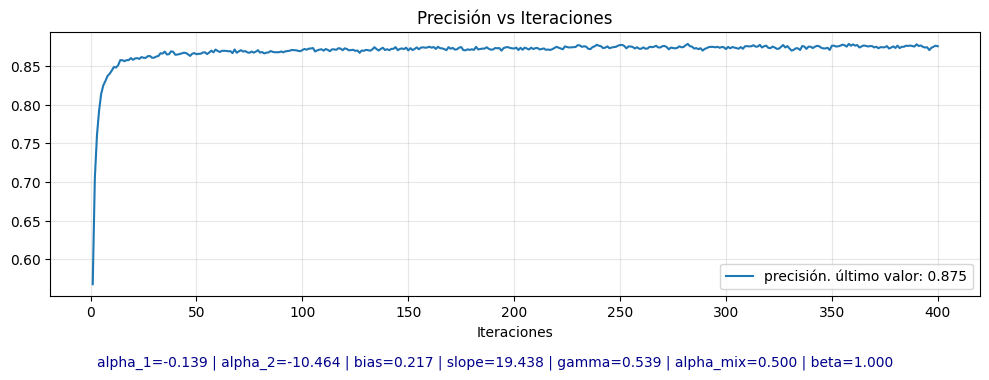


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.188  std:2.710
mask_bpsnr       : mean: 13.886  std:1.790
ssim             : mean: 0.799  std:0.090
acc_at_least_one : 0.990
acc_both         : 0.875



KeyboardInterrupt: 

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from project.loader import Loader
from project.CROP.models.crop2 import Crop2


'''
Aclaración sobre los parámetros
CROP usa los siguiente parametros:
bias, slope, alpha_1, alpha_2 gamma y beta.
Si no se especifica nada, se usan los valores por defecto.
Para usar parametros distintos, hay que pasarlos como un diccionaio (Ver MNIST_PARAMS)
'''

# config
DATASET = "mnist" # mnist o fashion
ITERATIONS = 400


MNIST_PARAMS = {
    'bias': 0.21716868437244724,
    'slope': 19.437646607877017,
    'alpha_1': -0.13863158439804657,
    'alpha_2': -10.463749682840565,
    'gamma': 0.5392507616026618
}


MODELS = [ # Modelos usados para comparar
    {"inter": 128, "lat": 2},
    {"inter": 128, "lat": 64},
    {"inter": 256, "lat": 64},
   {"inter": 256, "lat": 128},
   {"inter": 512, "lat": 128},
   {"inter": 512, "lat": 256},
   {"inter": 784, "lat": 784},
]


#Data & predictor
data = Loader.data(dataset=DATASET)
predictor = Loader.predictor(dataset=DATASET)

x_test, x_test_1 = data["x_test"], data["x_test_1"]
y_test, y_test_1 = data["y_test"], data["y_test_1"]


# Evaluation
results = {}

for model in MODELS:

    inter = model["inter"]
    lat = model["lat"]

    #cvae = Loader.cvae(lat=lat, inter=inter, dataset=DATASET)
    crop = Crop2(predictor=predictor, lat=lat,inter=inter,dataset=DATASET)

    metrics = crop.unmix( #Crop tiene un metodo para hacer esta curva de acc
        x_test, # primer conjunto de datos
        x_test_1, # Segundo conjunto de datos para mezclar
        y_test, # labels del primer conjunto
        y_test_1, # labels del segundo conjunto
        iterations=ITERATIONS,
        show_acc_curve=True,
        params=MNIST_PARAMS
    )

    results[(lat, inter)] = metrics


# -------------------- plot --------------------
for (lat, inter), m in results.items():
    acc = m["acc_both_plot"]
    plt.plot(
        acc,
        label=f"inter_{inter}_lat_{lat} "
              f"(max: {np.max(acc):.4f}, last: {acc[-1]:.4f})"
    )

plt.grid()
plt.title(f"Precisión vs iteraciones · dataset: {DATASET}")
plt.xlabel("iterations")
plt.ylabel("precision [%]")
plt.legend()
#plt.savefig(f"acc_both_classes_models_{DATASET}.png")
plt.show()


## Notas


comparacion de parametros con modelos 512 256

|Modelo/Dataset| mnist | Fashion | 
|:----------|:----------:|:------|
|CROP1|    0.8404      |    0.5955   |
|CROP2|     0.8478     | 0.6126      |
|CROP2_optim|   0.8602       | 0.6146      |
|CROP2_gamma| 0.842       | 0.6169      |


## compración de distintos modelos
todos crop 2



|Modelo/Dataset| mnist | Fashion | 
|:----------|:----------:|:------|
|2 128|    0.7499      |    0.5998   |
|64 128|     0.8516     | 0.6151     |
|128 256|   0.8643       | 0.6153      | 
|256 512| 0.8467       | 0.6129     |
|2 128 opt|    0.7659      |    0.6138   |
|64 128 opt|     0.8618     | 0.6267      |
|128 256 opt|   0.875       | 0.6257      |
|256 512 opt| 0.8601       | 0.6158      |
